# Sistemas Inteligentes I
## Búsqueda informada: Costo Uniforme, A* y Beam Search

**Autor:** Jairo I. Vélez B.

### Propósito
Estudiar tres estrategias para decidir qué nodo expandir primero usando el costo acumulado y, cuando corresponde, una heurística.

Al finalizar, el estudiante podrá:
- diferenciar búsqueda no informada e informada;
- interpretar $g(n)$, $h(n)$ y $f(n)$;
- implementar Costo Uniforme, A* y Beam Search;
- comparar costo, estados expandidos y calidad de solución;
- analizar el efecto de una heurística.

# 1. Idea central

En BFS y DFS la frontera se organiza sin estimar qué nodo está más cerca del objetivo. En búsqueda informada podemos incorporar información adicional.

- $g(n)$: costo acumulado desde el inicio hasta $n$.
- $h(n)$: estimación del costo desde $n$ hasta el objetivo.
- En A*: $f(n)=g(n)+h(n)$.

**Costo Uniforme:** prioriza menor $g(n)$.  
**A\*:** prioriza menor $g(n)+h(n)$.  
**Beam Search:** conserva solo los mejores $k$ candidatos de cada nivel.

In [1]:
from heapq import heappush, heappop
from itertools import count
import math
import matplotlib.pyplot as plt

print("Entorno listo")

Entorno listo


# 2. Problema base: grafo ponderado

- Estado inicial: `A`
- Objetivo: `G`
- Cada arista tiene un costo.

In [2]:
grafo = {
    "A": {"B": 2, "C": 4},
    "B": {"D": 5, "E": 10},
    "C": {"E": 3, "F": 6},
    "D": {"G": 4},
    "E": {"G": 2},
    "F": {"G": 3},
    "G": {}
}
grafo

{'A': {'B': 2, 'C': 4},
 'B': {'D': 5, 'E': 10},
 'C': {'E': 3, 'F': 6},
 'D': {'G': 4},
 'E': {'G': 2},
 'F': {'G': 3},
 'G': {}}

# 3. Búsqueda de Costo Uniforme (UCS)

Expande el nodo con menor costo acumulado:

$$f(n)=g(n)$$

No usa heurística. La frontera se implementa con una cola de prioridad.

In [3]:
def costo_uniforme(grafo, inicio, objetivo):
    orden = count()
    frontera = []
    heappush(frontera, (0, next(orden), inicio, [inicio]))
    mejor_g = {inicio: 0}
    expandidos = 0

    while frontera:
        g, _, nodo, camino = heappop(frontera)
        if g != mejor_g.get(nodo):
            continue
        expandidos += 1
        if nodo == objetivo:
            return {"camino": camino, "costo": g, "expandidos": expandidos}

        for vecino, costo in grafo[nodo].items():
            nuevo_g = g + costo
            if nuevo_g < mejor_g.get(vecino, math.inf):
                mejor_g[vecino] = nuevo_g
                heappush(frontera, (nuevo_g, next(orden), vecino, camino + [vecino]))
    return None

resultado_ucs = costo_uniforme(grafo, "A", "G")
resultado_ucs

{'camino': ['A', 'C', 'E', 'G'], 'costo': 9, 'expandidos': 6}

## 3.1 UCS paso a paso

In [4]:
def ucs_debug(grafo, inicio, objetivo):
    orden = count(); frontera=[]
    heappush(frontera,(0,next(orden),inicio,[inicio]))
    mejor_g={inicio:0}; paso=1
    while frontera:
        print(f"\nPaso {paso}")
        print("Frontera:", [(g,n) for g,_,n,_ in frontera])
        g,_,nodo,camino=heappop(frontera)
        if g != mejor_g.get(nodo):
            continue
        print(f"Expandimos {nodo}: g={g}")
        if nodo==objetivo: return camino,g
        for vecino,costo in grafo[nodo].items():
            ng=g+costo
            if ng < mejor_g.get(vecino, math.inf):
                mejor_g[vecino]=ng
                heappush(frontera,(ng,next(orden),vecino,camino+[vecino]))
        paso += 1

ucs_debug(grafo,"A","G")


Paso 1
Frontera: [(0, 'A')]
Expandimos A: g=0

Paso 2
Frontera: [(2, 'B'), (4, 'C')]
Expandimos B: g=2

Paso 3
Frontera: [(4, 'C'), (7, 'D'), (12, 'E')]
Expandimos C: g=4

Paso 4
Frontera: [(7, 'D'), (10, 'F'), (7, 'E'), (12, 'E')]
Expandimos D: g=7

Paso 5
Frontera: [(7, 'E'), (10, 'F'), (12, 'E'), (11, 'G')]
Expandimos E: g=7

Paso 6
Frontera: [(9, 'G'), (10, 'F'), (12, 'E'), (11, 'G')]
Expandimos G: g=9


(['A', 'C', 'E', 'G'], 9)

# 4. Heurística

Hasta ahora, **Costo Uniforme** solo utiliza información sobre el costo ya recorrido:

\[
g(n)
\]

Para orientar la búsqueda hacia el objetivo podemos incorporar una estimación:

\[
h(n)
\]

donde \(h(n)\) representa una **estimación del costo mínimo restante** desde el nodo \(n\) hasta el objetivo.

## ¿De dónde salen estos valores?

En un problema real, una heurística debe derivarse de alguna propiedad del dominio: distancia geométrica, cantidad de elementos fuera de lugar, una relajación del problema, conocimiento experto, etc.

En este grafo pequeño conocemos toda la estructura, por lo que podemos calcular el costo real mínimo desde cada nodo hasta `G`. Lo usaremos únicamente con fines didácticos para evaluar la calidad de una heurística.

In [5]:
# Costo real mínimo desde cada nodo hasta G.
# En un problema real normalmente NO conoceríamos estos valores de antemano.

costo_real_hasta_G = {
    "A": 9,
    "B": 9,
    "C": 5,
    "D": 4,
    "E": 2,
    "F": 3,
    "G": 0,
}

costo_real_hasta_G

{'A': 9, 'B': 9, 'C': 5, 'D': 4, 'E': 2, 'F': 3, 'G': 0}

## 4.1 Costo real vs. estimación heurística

Denotaremos el costo real mínimo restante como:

$$
h^*(n)
$$

La heurística $$h(n)$$ intenta aproximarlo:

$$
h(n)\approx h^*(n)
$$

Una heurística es **admisible** cuando nunca sobreestima el costo real:

$$
\boxed{h(n)\leq h^*(n)}
$$

Para este ejemplo utilizaremos una heurística **admisible pero imperfecta**:

| Nodo | $$h(n)$$ | $$h^*(n)$$ |
|---|---:|---:|
| A | 7 | 9 |
| B | 6 | 9 |
| C | 4 | 5 |
| D | 3 | 4 |
| E | 2 | 2 |
| F | 2 | 3 |
| G | 0 | 0 |

La heurística no conoce exactamente la solución: solo proporciona una estimación razonable.

In [6]:
heuristica = {
    "A": 7,
    "B": 6,
    "C": 4,
    "D": 3,
    "E": 2,
    "F": 2,
    "G": 0,
}

heuristica

{'A': 7, 'B': 6, 'C': 4, 'D': 3, 'E': 2, 'F': 2, 'G': 0}

In [7]:
# Verificación de admisibilidad
comparacion_heuristica = {
    nodo: {
        "h(n)": heuristica[nodo],
        "h*(n)": costo_real_hasta_G[nodo],
        "admisible": heuristica[nodo] <= costo_real_hasta_G[nodo],
    }
    for nodo in heuristica
}

comparacion_heuristica

{'A': {'h(n)': 7, 'h*(n)': 9, 'admisible': True},
 'B': {'h(n)': 6, 'h*(n)': 9, 'admisible': True},
 'C': {'h(n)': 4, 'h*(n)': 5, 'admisible': True},
 'D': {'h(n)': 3, 'h*(n)': 4, 'admisible': True},
 'E': {'h(n)': 2, 'h*(n)': 2, 'admisible': True},
 'F': {'h(n)': 2, 'h*(n)': 3, 'admisible': True},
 'G': {'h(n)': 0, 'h*(n)': 0, 'admisible': True}}

### Idea clave

> **La heurística no tiene que acertar exactamente. Tiene que estimar.**

Una heurística demasiado débil puede aportar poca información.  
Una heurística que sobreestima puede orientar de manera agresiva la búsqueda, pero puede perder garantías de optimalidad.

# 5. A*

A* combina costo acumulado y estimación:

$$\boxed{f(n)=g(n)+h(n)}$$

Se expande primero el nodo con menor $f(n)$.

In [8]:
def a_estrella(grafo, heuristica, inicio, objetivo):
    tie = count(); frontera=[]
    heappush(frontera,(heuristica[inicio],0,next(tie),inicio,[inicio]))
    mejor_g={inicio:0}; expandidos=0

    while frontera:
        f,g,_,nodo,camino = heappop(frontera)
        if g != mejor_g.get(nodo):
            continue
        expandidos += 1
        if nodo == objetivo:
            return {"camino":camino,"costo":g,"expandidos":expandidos}

        for vecino,costo in grafo[nodo].items():
            ng=g+costo
            if ng < mejor_g.get(vecino, math.inf):
                mejor_g[vecino]=ng
                nf=ng+heuristica[vecino]
                heappush(frontera,(nf,ng,next(tie),vecino,camino+[vecino]))
    return None

resultado_astar = a_estrella(grafo,heuristica,"A","G")
resultado_astar

{'camino': ['A', 'C', 'E', 'G'], 'costo': 9, 'expandidos': 5}

## 5.1 A* paso a paso

In [9]:
def astar_debug(grafo, heuristica, inicio, objetivo):
    tie=count(); frontera=[]
    heappush(frontera,(heuristica[inicio],0,next(tie),inicio,[inicio]))
    mejor_g={inicio:0}; paso=1
    while frontera:
        print(f"\nPaso {paso}")
        print("Frontera:", [(n,g,f) for f,g,_,n,_ in frontera])
        f,g,_,nodo,camino=heappop(frontera)
        if g != mejor_g.get(nodo): continue
        print(f"Expandimos {nodo}: g={g}, h={heuristica[nodo]}, f={f}")
        if nodo==objetivo: return camino,g
        for vecino,costo in grafo[nodo].items():
            ng=g+costo
            if ng < mejor_g.get(vecino, math.inf):
                mejor_g[vecino]=ng
                nf=ng+heuristica[vecino]
                heappush(frontera,(nf,ng,next(tie),vecino,camino+[vecino]))
        paso += 1

astar_debug(grafo,heuristica,"A","G")


Paso 1
Frontera: [('A', 0, 7)]
Expandimos A: g=0, h=7, f=7

Paso 2
Frontera: [('B', 2, 8), ('C', 4, 8)]
Expandimos B: g=2, h=6, f=8

Paso 3
Frontera: [('C', 4, 8), ('D', 7, 10), ('E', 12, 14)]
Expandimos C: g=4, h=4, f=8

Paso 4
Frontera: [('E', 7, 9), ('F', 10, 12), ('D', 7, 10), ('E', 12, 14)]
Expandimos E: g=7, h=2, f=9

Paso 5
Frontera: [('G', 9, 9), ('D', 7, 10), ('E', 12, 14), ('F', 10, 12)]
Expandimos G: g=9, h=0, f=9


(['A', 'C', 'E', 'G'], 9)

## 5.2 Tres casos para entender el papel de la heurística

Antes de comparar los algoritmos, observemos qué ocurre con A* bajo tres configuraciones distintas de \(h(n)\).

### Caso 1 — Sin heurística

Si:

$$
h(n)=0 \quad \forall n
$$

entonces:

$$
f(n)=g(n)
$$

y A* se comporta como **Costo Uniforme**.

In [10]:
heuristica_cero = {nodo: 0 for nodo in grafo}

resultado_astar_h0 = a_estrella(
    grafo,
    heuristica_cero,
    "A",
    "G"
)

resultado_astar_h0

{'camino': ['A', 'C', 'E', 'G'], 'costo': 9, 'expandidos': 6}

### Caso 2 — Heurística admisible

Usamos la heurística definida anteriormente:

$$
h(n)\leq h^*(n)
$$

La búsqueda dispone de información para orientar la expansión sin sobreestimar el costo real restante.

In [11]:
resultado_astar_admisible = a_estrella(
    grafo,
    heuristica,
    "A",
    "G"
)

resultado_astar_admisible

{'camino': ['A', 'C', 'E', 'G'], 'costo': 9, 'expandidos': 5}

### Caso 3 — Heurística que sobreestima

Ahora construiremos deliberadamente una heurística **no admisible**.

Algunos valores cumplen:

$$
h(n)>h^*(n)
$$

Esto no significa que A* necesariamente encuentre una mala solución, pero ya no podemos asumir las mismas garantías de optimalidad.

In [12]:
heuristica_sobreestima = {
    "A": 12,  # costo real = 9
    "B": 10,  # costo real = 9
    "C": 4,
    "D": 3,
    "E": 7,   # costo real = 2
    "F": 2,
    "G": 0,
}

comparacion_sobreestimacion = {
    nodo: {
        "h(n)": heuristica_sobreestima[nodo],
        "h*(n)": costo_real_hasta_G[nodo],
        "sobreestima": heuristica_sobreestima[nodo] > costo_real_hasta_G[nodo],
    }
    for nodo in heuristica_sobreestima
}

comparacion_sobreestimacion

{'A': {'h(n)': 12, 'h*(n)': 9, 'sobreestima': True},
 'B': {'h(n)': 10, 'h*(n)': 9, 'sobreestima': True},
 'C': {'h(n)': 4, 'h*(n)': 5, 'sobreestima': False},
 'D': {'h(n)': 3, 'h*(n)': 4, 'sobreestima': False},
 'E': {'h(n)': 7, 'h*(n)': 2, 'sobreestima': True},
 'F': {'h(n)': 2, 'h*(n)': 3, 'sobreestima': False},
 'G': {'h(n)': 0, 'h*(n)': 0, 'sobreestima': False}}

In [13]:
resultado_astar_sobreestima = a_estrella(
    grafo,
    heuristica_sobreestima,
    "A",
    "G"
)

resultado_astar_sobreestima

{'camino': ['A', 'B', 'D', 'G'], 'costo': 11, 'expandidos': 5}

### Comparación de los tres casos

Compare:

- camino encontrado,
- costo total,
- nodos expandidos.

La idea importante es que una heurística no admisible **no necesariamente falla siempre**; simplemente deja de cumplir las condiciones que permiten garantizar la optimalidad de A*.

In [14]:
comparacion_tres_heuristicas = {
    "h(n)=0": resultado_astar_h0,
    "Admisible": resultado_astar_admisible,
    "Sobreestima": resultado_astar_sobreestima,
}

comparacion_tres_heuristicas

{'h(n)=0': {'camino': ['A', 'C', 'E', 'G'], 'costo': 9, 'expandidos': 6},
 'Admisible': {'camino': ['A', 'C', 'E', 'G'], 'costo': 9, 'expandidos': 5},
 'Sobreestima': {'camino': ['A', 'B', 'D', 'G'], 'costo': 11, 'expandidos': 5}}

### ✅ Solución — interpretación de los tres casos

| Caso | Camino | Costo | Expandidos |
|---|---|---:|---:|
| $h(n)=0$ | A → C → E → G | 9 | 6 |
| Admisible | A → C → E → G | 9 | 5 |
| Sobreestima | A → B → D → G | **11** | 5 |

- **h = 0:** $f(n)=g(n)$, así que A* hace exactamente lo mismo que Costo Uniforme (6 expansiones, costo óptimo 9).
- **Admisible:** encuentra el mismo camino óptimo pero expande **un nodo menos**: al llegar a D con $f=7+3=10$, ya tenía E con $f=9$, así que D nunca se expande.
- **Sobreestima:** $h(E)=7$ cuando el costo real es 2. Eso hace que E parezca malo ($f(E)=7+7=14$), la búsqueda se va por D y devuelve un camino de costo **11 en lugar de 9**. Es el ejemplo típico de pérdida de optimalidad.

# 6. Comparación inicial

**Pregunta clave:** ¿qué ocurre si $h(n)=0$ para todos los nodos?  
A* se comporta como Costo Uniforme.

In [15]:
{
    "Costo Uniforme": resultado_ucs,
    "A*": resultado_astar
}

{'Costo Uniforme': {'camino': ['A', 'C', 'E', 'G'],
  'costo': 9,
  'expandidos': 6},
 'A*': {'camino': ['A', 'C', 'E', 'G'], 'costo': 9, 'expandidos': 5}}

# 7. Caso aplicado: cuadrícula

Ahora trabajaremos con un mapa:

- `0`: celda libre
- `1`: obstáculo
- acciones: arriba, abajo, izquierda y derecha
- costo de cada movimiento: 1

Para A* usaremos distancia Manhattan:

$$h(n)=|x_n-x_g|+|y_n-y_g|$$

In [16]:
mapa = [
    [0,0,0,0,0,0,0],
    [0,1,1,1,0,1,0],
    [0,0,0,1,0,1,0],
    [1,1,0,1,0,0,0],
    [0,0,0,0,1,1,0],
    [0,1,1,0,0,0,0],
    [0,0,0,0,1,0,0],
]
INICIO=(0,0); OBJETIVO=(6,6)
MOVIMIENTOS=[(1,0),(-1,0),(0,1),(0,-1)]

def sucesores_mapa(mapa,pos):
    filas=len(mapa); cols=len(mapa[0]); f,c=pos; out=[]
    for df,dc in MOVIMIENTOS:
        nf,nc=f+df,c+dc
        if 0<=nf<filas and 0<=nc<cols and mapa[nf][nc]==0:
            out.append((nf,nc))
    return out

def manhattan(a,b):
    return abs(a[0]-b[0])+abs(a[1]-b[1])

## 7.1 Costo Uniforme en la cuadrícula

In [17]:
def ucs_mapa(mapa,inicio,objetivo):
    tie=count(); frontera=[(0,next(tie),inicio,[inicio])]
    mejor_g={inicio:0}; expandidos=0
    while frontera:
        g,_,nodo,camino=heappop(frontera)
        if g != mejor_g.get(nodo): continue
        expandidos += 1
        if nodo==objetivo:
            return {"camino":camino,"costo":g,"expandidos":expandidos}
        for vecino in sucesores_mapa(mapa,nodo):
            ng=g+1
            if ng < mejor_g.get(vecino, math.inf):
                mejor_g[vecino]=ng
                heappush(frontera,(ng,next(tie),vecino,camino+[vecino]))
    return None

resultado_ucs_mapa=ucs_mapa(mapa,INICIO,OBJETIVO)
resultado_ucs_mapa

{'camino': [(0, 0),
  (1, 0),
  (2, 0),
  (2, 1),
  (2, 2),
  (3, 2),
  (4, 2),
  (4, 3),
  (5, 3),
  (5, 4),
  (5, 5),
  (6, 5),
  (6, 6)],
 'costo': 12,
 'expandidos': 35}

## 7.2 A* en la cuadrícula

In [18]:
def astar_mapa(mapa,inicio,objetivo):
    tie=count(); frontera=[(manhattan(inicio,objetivo),0,next(tie),inicio,[inicio])]
    mejor_g={inicio:0}; expandidos=0
    while frontera:
        f,g,_,nodo,camino=heappop(frontera)
        if g != mejor_g.get(nodo): continue
        expandidos += 1
        if nodo==objetivo:
            return {"camino":camino,"costo":g,"expandidos":expandidos}
        for vecino in sucesores_mapa(mapa,nodo):
            ng=g+1
            if ng < mejor_g.get(vecino, math.inf):
                mejor_g[vecino]=ng
                nf=ng+manhattan(vecino,objetivo)
                heappush(frontera,(nf,ng,next(tie),vecino,camino+[vecino]))
    return None

resultado_astar_mapa=astar_mapa(mapa,INICIO,OBJETIVO)
resultado_astar_mapa

{'camino': [(0, 0),
  (1, 0),
  (2, 0),
  (2, 1),
  (2, 2),
  (3, 2),
  (4, 2),
  (4, 3),
  (5, 3),
  (5, 4),
  (5, 5),
  (6, 5),
  (6, 6)],
 'costo': 12,
 'expandidos': 29}

## 7.3 Visualización

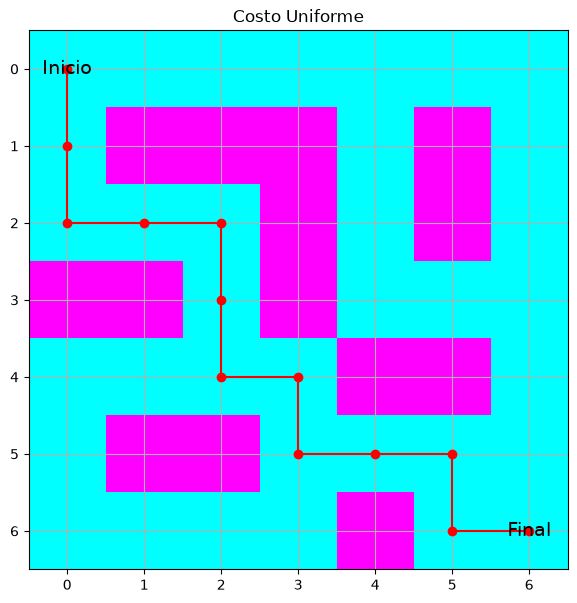

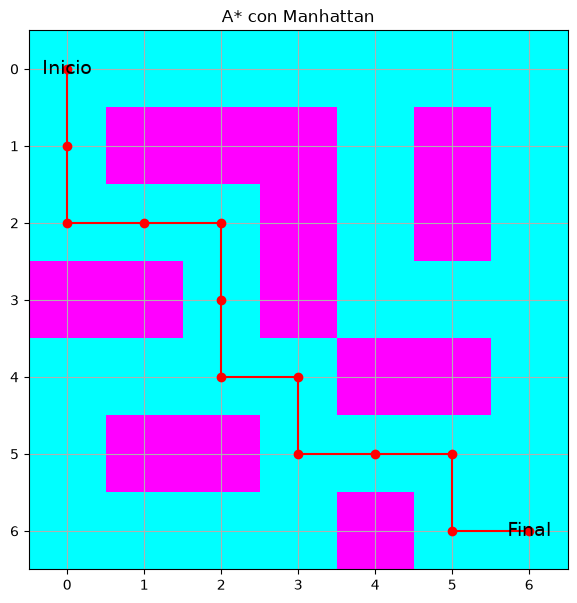

In [19]:
def mostrar_mapa(mapa, camino=None, inicio=None, objetivo=None, titulo="Mapa"):
    fig,ax=plt.subplots(figsize=(7,7))
    ax.imshow(mapa,cmap='cool')
    if camino:
        xs=[c for f,c in camino]; ys=[f for f,c in camino]
        ax.plot(xs,ys,c='red',marker="o")
    if inicio: ax.text(inicio[1],inicio[0],"Inicio",ha="center",va="center",fontsize=14)
    if objetivo: ax.text(objetivo[1],objetivo[0],"Final",ha="center",va="center",fontsize=14)
    ax.set_xticks(range(len(mapa[0]))); ax.set_yticks(range(len(mapa)))
    ax.set_title(titulo); ax.grid(True); plt.show()

mostrar_mapa(mapa,resultado_ucs_mapa["camino"],INICIO,OBJETIVO,"Costo Uniforme")
mostrar_mapa(mapa,resultado_astar_mapa["camino"],INICIO,OBJETIVO,"A* con Manhattan")

## 7.4 Comparación experimental

In [20]:
{
    "Costo Uniforme": {"costo":resultado_ucs_mapa["costo"],"expandidos":resultado_ucs_mapa["expandidos"]},
    "A*": {"costo":resultado_astar_mapa["costo"],"expandidos":resultado_astar_mapa["expandidos"]}
}

{'Costo Uniforme': {'costo': 12, 'expandidos': 35},
 'A*': {'costo': 12, 'expandidos': 29}}

# 8. Beam Search

Beam Search limita deliberadamente la cantidad de estados conservados en cada nivel.

$$k=\text{beam width}$$

Si $k=2$, solo se mantienen los dos estados más prometedores del nivel.

Ventaja: reduce memoria y exploración.  
Riesgo: puede descartar un estado que conduzca a la mejor solución. Por eso no garantiza optimalidad y puede fallar aunque exista solución.

In [21]:
def beam_search_mapa(mapa,inicio,objetivo,beam_width=2):
    haz=[(inicio,[inicio])]
    visitados={inicio}
    expandidos=0

    while haz:
        candidatos=[]
        for nodo,camino in haz:
            expandidos += 1
            if nodo==objetivo:
                return {"camino":camino,"costo":len(camino)-1,"expandidos":expandidos,"beam_width":beam_width}
            for vecino in sucesores_mapa(mapa,nodo):
                if vecino not in visitados:
                    visitados.add(vecino)
                    candidatos.append((vecino,camino+[vecino]))

        candidatos.sort(key=lambda x: manhattan(x[0],objetivo))
        haz=candidatos[:beam_width]
    return None

resultado_beam=beam_search_mapa(mapa,INICIO,OBJETIVO,beam_width=3)
resultado_beam

{'camino': [(0, 0),
  (1, 0),
  (2, 0),
  (2, 1),
  (2, 2),
  (3, 2),
  (4, 2),
  (4, 3),
  (5, 3),
  (5, 4),
  (5, 5),
  (6, 5),
  (6, 6)],
 'costo': 12,
 'expandidos': 31,
 'beam_width': 3}

## 8.1 Experimentar con diferentes anchos de haz

In [22]:
resultados_beam={}
for k in [1,2,3,5,10]:
    resultados_beam[k]=beam_search_mapa(mapa,INICIO,OBJETIVO,beam_width=k)
resultados_beam

{1: None,
 2: {'camino': [(0, 0),
   (1, 0),
   (2, 0),
   (2, 1),
   (2, 2),
   (3, 2),
   (4, 2),
   (4, 3),
   (5, 3),
   (5, 4),
   (5, 5),
   (6, 5),
   (6, 6)],
  'costo': 12,
  'expandidos': 24,
  'beam_width': 2},
 3: {'camino': [(0, 0),
   (1, 0),
   (2, 0),
   (2, 1),
   (2, 2),
   (3, 2),
   (4, 2),
   (4, 3),
   (5, 3),
   (5, 4),
   (5, 5),
   (6, 5),
   (6, 6)],
  'costo': 12,
  'expandidos': 31,
  'beam_width': 3},
 5: {'camino': [(0, 0),
   (1, 0),
   (2, 0),
   (2, 1),
   (2, 2),
   (3, 2),
   (4, 2),
   (4, 3),
   (5, 3),
   (5, 4),
   (5, 5),
   (6, 5),
   (6, 6)],
  'costo': 12,
  'expandidos': 35,
  'beam_width': 5},
 10: {'camino': [(0, 0),
   (1, 0),
   (2, 0),
   (2, 1),
   (2, 2),
   (3, 2),
   (4, 2),
   (4, 3),
   (5, 3),
   (5, 4),
   (5, 5),
   (6, 5),
   (6, 6)],
  'costo': 12,
  'expandidos': 35,
  'beam_width': 10}}

# 9. Comparación global

In [23]:
{
    "Costo Uniforme": {"costo":resultado_ucs_mapa["costo"],"expandidos":resultado_ucs_mapa["expandidos"]},
    "A*": {"costo":resultado_astar_mapa["costo"],"expandidos":resultado_astar_mapa["expandidos"]},
    "Beam Search k=3": None if resultado_beam is None else {"costo":resultado_beam["costo"],"expandidos":resultado_beam["expandidos"]}
}

{'Costo Uniforme': {'costo': 12, 'expandidos': 35},
 'A*': {'costo': 12, 'expandidos': 29},
 'Beam Search k=3': {'costo': 12, 'expandidos': 31}}

## 9.1 Resumen conceptual

| Algoritmo | Prioriza | Heurística | ¿Óptimo? | Memoria |
|---|---|---:|---|---|
| Costo Uniforme | menor $g(n)$ | No | Sí, con costos no negativos | Puede ser alta |
| A* | menor $g(n)+h(n)$ | Sí | Sí, bajo condiciones adecuadas | Puede ser alta |
| Beam Search | mejores $k$ candidatos | Sí | No garantizado | Controlada |

**Idea clave:**
- Costo Uniforme sabe cuánto ha costado llegar.
- A* sabe cuánto ha costado llegar y estima cuánto falta.
- Beam Search sacrifica exhaustividad para controlar el tamaño de la búsqueda.

# 10. Interpretación de la calidad de una heurística

Ya observamos tres escenarios:

- **Heurística nula:** no aporta información y A* se reduce a Costo Uniforme.
- **Heurística admisible:** orienta la búsqueda sin sobreestimar el costo real restante.
- **Heurística no admisible:** puede priorizar de forma agresiva ciertos caminos, pero pierde la garantía de optimalidad.

### Para discutir

1. ¿Una heurística con valores más grandes es necesariamente mejor?
2. ¿Qué diferencia existe entre una heurística **informativa** y una heurística que simplemente sobreestima?
3. ¿Por qué no podemos usar \(h^*(n)\) directamente como heurística en un problema real?
4. ¿Qué ocurriría si calcular \(h(n)\) fuera casi tan costoso como resolver el problema?
5. ¿Qué propiedades del dominio podrían utilizarse para construir una buena heurística?

### ✅ Respuestas — Para discutir

1. **¿Valores más grandes = mejor?** Solo *mientras sigan siendo admisibles*. Si $h_2(n)\ge h_1(n)$ para todo $n$ y ambas son admisibles, $h_2$ **domina** a $h_1$ y A* con $h_2$ nunca expande más nodos. Pero si los valores superan $h^*(n)$, se pierde la garantía de optimalidad (caso 3: costo 11 en vez de 9).
2. **Informativa vs. sobreestimar:** una heurística informativa se acerca a $h^*$ **desde abajo** (ej. Manhattan vs. fichas fuera de lugar). Una que sobreestima se pasa del valor real: puede ir más rápido, pero puede descartar el camino óptimo porque lo hace ver más caro de lo que es.
3. **¿Por qué no usar $h^*(n)$?** Porque para conocer el costo real mínimo hasta el objetivo hay que **resolver el problema** desde cada nodo. Si ya lo sabemos, no necesitamos buscar.
4. **Si calcular $h$ fuera casi tan costoso como resolver:** el ahorro de nodos expandidos se pierde en el tiempo de cálculo de $h$. Una buena heurística equilibra **precisión** y **costo de cómputo**.
5. **Propiedades del dominio útiles:** distancias geométricas (Manhattan, euclidiana), **relajar el problema** (quitar restricciones: "las fichas pueden atravesarse" → Manhattan; "una ficha puede teletransportarse" → fichas fuera de lugar), bases de datos de patrones, conocimiento experto, cotas inferiores físicas (velocidad máxima, costo mínimo por acción).

# 11. Reto: A* para el 8-puzzle

Compare tres estrategias sobre el mismo problema:

1. BFS
2. A* con fichas fuera de lugar
3. A* con distancia Manhattan

Mida:
- longitud de la solución;
- estados expandidos;
- tiempo de ejecución.

Heurísticas sugeridas:

$$h_1(n)=\text{número de fichas fuera de lugar}$$

$$h_2(n)=\sum_i (|x_i-x_i^*|+|y_i-y_i^*|)$$

In [24]:
from collections import deque
import time

OBJETIVO_8 = (1,2,3,4,5,6,7,8,0)  # 0 = hueco

def sucesores_8(estado):
    i = estado.index(0)
    f, c = divmod(i, 3)
    vecinos = []
    for df, dc in [(-1,0),(1,0),(0,-1),(0,1)]:
        nf, nc = f+df, c+dc
        if 0 <= nf < 3 and 0 <= nc < 3:
            j = nf*3 + nc
            nuevo = list(estado)
            nuevo[i], nuevo[j] = nuevo[j], nuevo[i]
            vecinos.append(tuple(nuevo))
    return vecinos

# h1: fichas fuera de su posicion final
def h1_fuera_de_lugar(estado):
    fuera = 0
    for i in range(9):
        if estado[i] != 0 and estado[i] != OBJETIVO_8[i]:
            fuera += 1
    return fuera

# h2: suma de distancias Manhattan de cada ficha a su objetivo
def h2_manhattan(estado):
    total = 0
    for i in range(9):
        if estado[i] == 0:
            continue
        f, c = divmod(i, 3)
        idx_obj = OBJETIVO_8.index(estado[i])
        fo, co = divmod(idx_obj, 3)
        total += abs(f-fo) + abs(c-co)
    return total

def bfs_8_puzzle(inicio, objetivo):
    t0 = time.time()
    cola = deque([(inicio, [inicio])])
    visitados = {inicio}
    expandidos = 0
    while cola:
        estado, camino = cola.popleft()
        expandidos += 1
        if estado == objetivo:
            return {"longitud": len(camino)-1, "expandidos": expandidos,
                    "tiempo_s": round(time.time()-t0, 4), "camino": camino}
        for s in sucesores_8(estado):
            if s not in visitados:
                visitados.add(s)
                cola.append((s, camino+[s]))
    return None

def astar_8_puzzle(inicio, objetivo, h):
    t0 = time.time()
    tie = count()
    frontera = [(h(inicio), 0, next(tie), inicio, [inicio])]
    mejor_g = {inicio: 0}
    expandidos = 0
    while frontera:
        f, g, _, estado, camino = heappop(frontera)
        if g != mejor_g.get(estado):
            continue
        expandidos += 1
        if estado == objetivo:
            return {"longitud": g, "expandidos": expandidos,
                    "tiempo_s": round(time.time()-t0, 4), "camino": camino}
        for s in sucesores_8(estado):
            ng = g + 1
            if ng < mejor_g.get(s, math.inf):
                mejor_g[s] = ng
                heappush(frontera, (ng+h(s), ng, next(tie), s, camino+[s]))
    return None


### ✅ Solución del reto — cómo funciona

- **Estado:** una tupla de 9 números (0 = hueco), fácil de guardar en diccionarios.
- **Acciones:** mover el hueco arriba/abajo/izquierda/derecha; cada movimiento cuesta 1.
- **Resolubilidad:** con el objetivo `1 2 3 / 4 5 6 / 7 8 _`, un estado solo tiene solución si el número de **inversiones** es par. Si no se verifica, BFS recorre las 181 440 configuraciones alcanzables y devuelve `None`.
- **h1 (fuera de lugar):** admisible porque cada ficha mal ubicada necesita al menos 1 movimiento.
- **h2 (Manhattan):** admisible porque cada ficha necesita al menos tantos movimientos como su distancia Manhattan, y cada movimiento mueve una sola ficha una casilla. Además $h_2\ge h_1$ siempre, así que **h2 domina a h1**.

In [25]:
casos_8 = {
    "Fácil (6 mov.)":       (4,1,3,7,2,6,0,5,8),
    "Medio (12 mov.)":      (5,1,3,4,0,2,7,8,6),
    "Difícil (20 mov.)":    (7,2,4,5,0,6,8,3,1),
    "Muy difícil (31 mov.)":(8,6,7,2,5,4,3,0,1),
}

print(f"{'Caso':<24}{'Algoritmo':<20}{'Long.':>6}{'Expandidos':>12}{'Tiempo (s)':>12}")
for nombre, estado in casos_8.items():
    r = bfs_8_puzzle(estado, OBJETIVO_8)
    print(f"{nombre:<24}{'BFS':<20}{r['longitud']:>6}{r['expandidos']:>12}{r['tiempo_s']:>12}")
    r = astar_8_puzzle(estado, OBJETIVO_8, h1_fuera_de_lugar)
    print(f"{nombre:<24}{'A* h1':<20}{r['longitud']:>6}{r['expandidos']:>12}{r['tiempo_s']:>12}")
    r = astar_8_puzzle(estado, OBJETIVO_8, h2_manhattan)
    print(f"{nombre:<24}{'A* h2':<20}{r['longitud']:>6}{r['expandidos']:>12}{r['tiempo_s']:>12}")


Caso                    Algoritmo            Long.  Expandidos  Tiempo (s)
Fácil (6 mov.)          BFS                      6          53      0.0002
Fácil (6 mov.)          A* h1                    6           7      0.0001
Fácil (6 mov.)          A* h2                    6           7      0.0001
Medio (12 mov.)         BFS                     12        2345      0.0063
Medio (12 mov.)         A* h1                   12         143      0.0011
Medio (12 mov.)         A* h2                   12          76       0.001


Difícil (20 mov.)       BFS                     20       55409      0.2228
Difícil (20 mov.)       A* h1                   20        3667      0.0222
Difícil (20 mov.)       A* h2                   20         283      0.0023


Muy difícil (31 mov.)   BFS                     31      181439      0.8678


Muy difícil (31 mov.)   A* h1                   31      143849      1.6657


Muy difícil (31 mov.)   A* h2                   31       21198      0.4036


In [26]:
def mostrar_solucion_8(camino):
    for paso, e in enumerate(camino):
        print(f"Paso {paso}")
        for i in range(0, 9, 3):
            fila = ""
            for x in e[i:i+3]:
                if x == 0:
                    fila += "_ "
                else:
                    fila += str(x) + " "
            print(fila)
        print()

mostrar_solucion_8(astar_8_puzzle(casos_8["Fácil (6 mov.)"], OBJETIVO_8, h2_manhattan)["camino"])


Paso 0
4 1 3 
7 2 6 
_ 5 8 

Paso 1
4 1 3 
_ 2 6 
7 5 8 

Paso 2
_ 1 3 
4 2 6 
7 5 8 

Paso 3
1 _ 3 
4 2 6 
7 5 8 

Paso 4
1 2 3 
4 _ 6 
7 5 8 

Paso 5
1 2 3 
4 5 6 
7 _ 8 

Paso 6
1 2 3 
4 5 6 
7 8 _ 



**Lectura de resultados:** los tres algoritmos encuentran la **misma longitud** (todos son óptimos aquí: BFS porque los costos son uniformes, A* porque h1 y h2 son admisibles). La diferencia está en el esfuerzo: en el caso de 20 movimientos BFS expande ~55 000 estados, h1 ~3 700 y h2 ~280. En el caso de 31 movimientos, BFS y h1 prácticamente recorren todo el espacio; h2 expande ~7 veces menos. Nota curiosa: A* con h1 puede tardar **más tiempo** que BFS en el caso más difícil, porque expande casi lo mismo pero paga el costo extra de la cola de prioridad y de calcular $h$ (conecta con la pregunta 4 de discusión).

# 12. Preguntas de cierre

1. ¿Cuál es la diferencia entre $g(n)$ y $h(n)$?
2. ¿Por qué Costo Uniforme no es una búsqueda heurística?
3. ¿Por qué A* puede expandir menos nodos que Costo Uniforme?
4. ¿Qué pierde Beam Search al limitar la frontera?
5. ¿Qué algoritmo elegiría si necesita garantizar la solución de menor costo?
6. ¿Cuál elegiría si dispone de memoria muy limitada?
7. ¿Qué papel cumple la calidad de la heurística?

### ✅ Respuestas — Preguntas de cierre

1. **$g(n)$ vs $h(n)$:** $g(n)$ es el costo **real y conocido** desde el inicio hasta $n$; $h(n)$ es una **estimación** del costo que falta desde $n$ hasta el objetivo.
2. **UCS no es heurística** porque solo usa $g(n)$, información del pasado; no tiene ninguna estimación de qué tan cerca está el objetivo.
3. **A* expande menos que UCS** porque $h(n)$ penaliza los nodos que se alejan del objetivo; UCS se expande en "círculos" de igual costo en todas las direcciones, A* se estira hacia el objetivo (grafo: 5 vs 6; mapa 7×7: 29 vs 35).
4. **Beam Search pierde completitud y optimalidad:** al quedarse solo con $k$ candidatos puede descartar el único camino (o el más barato) hacia la meta. Con $k=1$ en el mapa 7×7 no encuentra solución.
5. **Garantizar el menor costo:** A* con heurística admisible (o UCS si no hay buena heurística).
6. **Memoria muy limitada:** Beam Search (memoria acotada por $k$), aceptando que puede fallar o dar soluciones peores. Alternativas óptimas con poca memoria: IDA* o SMA*.
7. **Calidad de la heurística:** determina cuántos nodos se expanden (más cercana a $h^*$ = menos expansiones) y si se conserva la optimalidad (admisible = sí, sobreestima = no garantizado).

# 13. Taller posterior

### Parte 1 — Cuadrícula
Construya un mapa de al menos `12 × 12` y ejecute:
- Costo Uniforme;
- A*;
- Beam Search con `k = 1, 2, 4, 8`.

Compare costo de solución, estados expandidos y capacidad para encontrar solución.

### Parte 2 — Heurísticas
Implemente dos heurísticas distintas para A* y analice cuál orienta mejor la búsqueda.

### Parte 3 — 8-puzzle
Implemente A* con fichas fuera de lugar y distancia Manhattan y compare con BFS.

### Pregunta final
**¿Puede una búsqueda más rápida producir una solución peor? Explique usando sus experimentos.**

### Uso de IA generativa
Si utiliza IA generativa, indique herramienta, propósito y partes de la actividad en las que fue utilizada. Debe poder explicar y defender completamente el trabajo entregado.

# ✅ Solución del Taller

## Parte 1 — Cuadrícula 12 × 12
Mapa con ~30 % de obstáculos. Inicio `(0,0)`, objetivo `(11,11)`.

In [27]:
mapa12 = [
    [0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1],
    [0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1],
    [0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1],
    [0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0],
    [1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0],
    [1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0],
    [1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1],
    [0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
]
INICIO12, OBJETIVO12 = (0, 0), (11, 11)

res12 = {
    "Costo Uniforme": ucs_mapa(mapa12, INICIO12, OBJETIVO12),
    "A* (Manhattan)": astar_mapa(mapa12, INICIO12, OBJETIVO12),
}
for k in [1, 2, 4, 8]:
    res12[f"Beam k={k}"] = beam_search_mapa(mapa12, INICIO12, OBJETIVO12, beam_width=k)

print(f"{'Algoritmo':<18}{'¿Encontró?':>11}{'Costo':>7}{'Expandidos':>12}")
for nombre, r in res12.items():
    if r is None:
        print(f"{nombre:<18}{'No':>11}{'-':>7}{'-':>12}")
    else:
        print(f"{nombre:<18}{'Sí':>11}{r['costo']:>7}{r['expandidos']:>12}")

Algoritmo          ¿Encontró?  Costo  Expandidos
Costo Uniforme             Sí     22          95
A* (Manhattan)             Sí     22          60
Beam k=1                   No      -           -
Beam k=2                   Sí     32          55
Beam k=4                   Sí     26          61
Beam k=8                   Sí     22          94


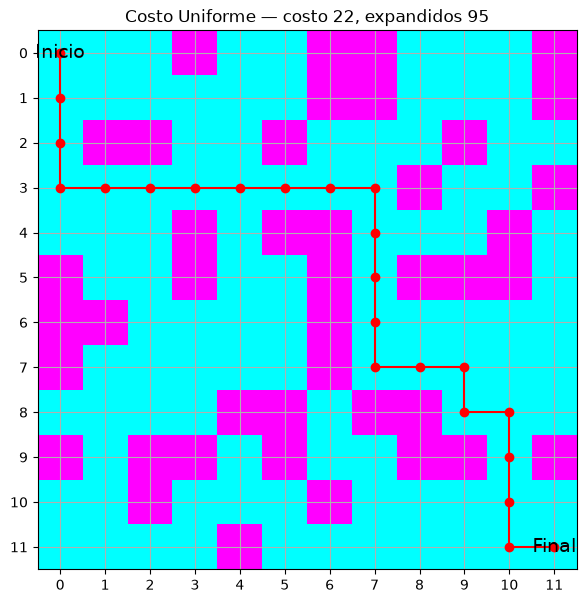

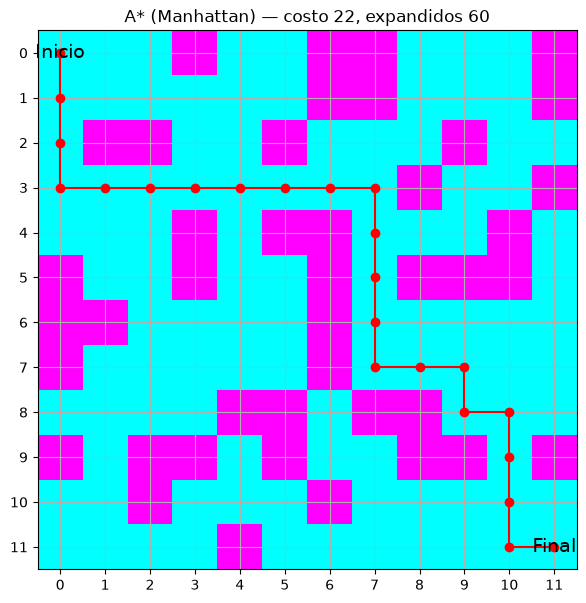

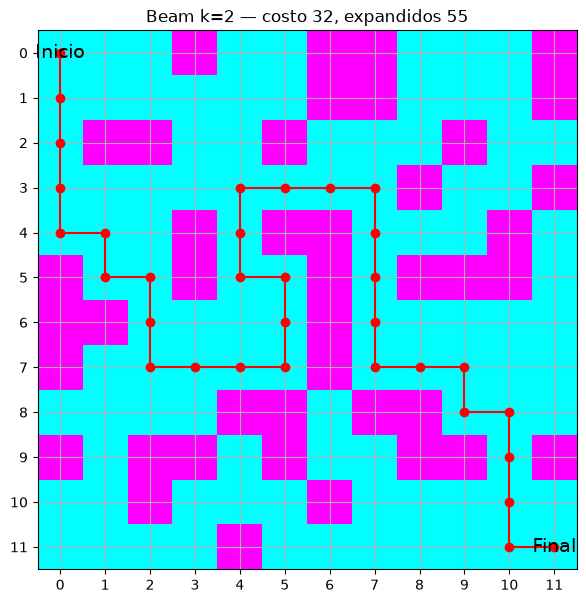

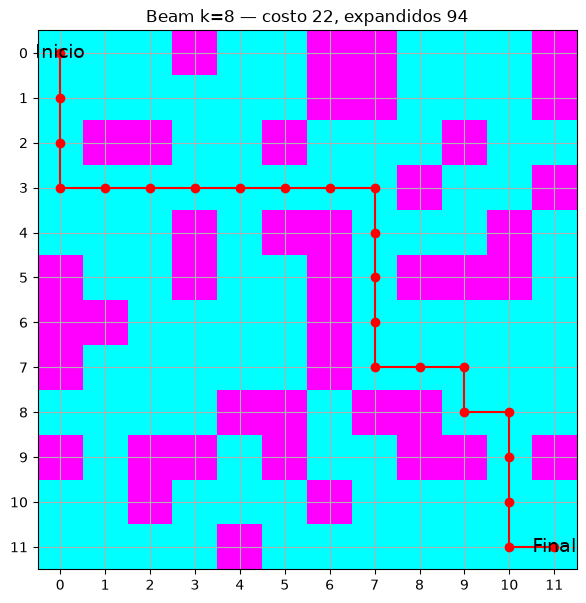

In [28]:
for nombre in ["Costo Uniforme", "A* (Manhattan)", "Beam k=2", "Beam k=8"]:
    r = res12[nombre]
    mostrar_mapa(mapa12, r["camino"], INICIO12, OBJETIVO12, f"{nombre} — costo {r['costo']}, expandidos {r['expandidos']}")

**Análisis Parte 1**

- **UCS y A\*** encuentran el costo óptimo (22). A* lo hace con **60** expansiones frente a **95** de UCS (~37 % menos).
- **Beam k=1** se comporta como una búsqueda voraz sin retroceso: entra en un callejón y **no encuentra solución** aunque existe.
- **Beam k=2 y k=4** encuentran solución pero **más cara** (32 y 26): el haz descartó en algún nivel el estado que llevaba al camino óptimo.
- **Beam k=8** ya conserva suficientes candidatos y llega al óptimo, pero expande casi tanto como UCS (94).
- Conclusión: al aumentar $k$ Beam Search gana calidad y completitud a cambio de más exploración; en el límite ($k\to\infty$) se vuelve una búsqueda por niveles completa.

## Parte 2 — Dos (o más) heurísticas para A*

Generalizamos A* para recibir la heurística como parámetro y comparamos:
- $h=0$ (equivale a UCS),
- **Euclidiana** $\sqrt{\Delta x^2+\Delta y^2}$ — admisible,
- **Manhattan** $|\Delta x|+|\Delta y|$ — admisible y exacta si no hubiera obstáculos,
- **3 × Manhattan** — **no admisible**, para ver el efecto de sobreestimar.

In [29]:
def astar_mapa_h(mapa, inicio, objetivo, h):
    tie = count()
    frontera = [(h(inicio,objetivo), 0, next(tie), inicio, [inicio])]
    mejor_g = {inicio: 0}
    expandidos = 0
    while frontera:
        f, g, _, nodo, camino = heappop(frontera)
        if g != mejor_g.get(nodo):
            continue
        expandidos += 1
        if nodo == objetivo:
            return {"camino": camino, "costo": g, "expandidos": expandidos}
        for vecino in sucesores_mapa(mapa, nodo):
            ng = g + 1
            if ng < mejor_g.get(vecino, math.inf):
                mejor_g[vecino] = ng
                heappush(frontera, (ng+h(vecino,objetivo), ng, next(tie), vecino, camino+[vecino]))
    return None

def h_cero(a,b):
    return 0

def h_euclidiana(a,b):
    return math.sqrt((a[0]-b[0])**2 + (a[1]-b[1])**2)

def h_manhattan(a,b):
    return abs(a[0]-b[0]) + abs(a[1]-b[1])

def h_mala(a,b):
    # sobreestima el costo real, no admisible
    return 3 * h_manhattan(a,b)

heuristicas = {
    "h = 0": h_cero,
    "Euclidiana": h_euclidiana,
    "Manhattan": h_manhattan,
    "3×Manhattan (no admisible)": h_mala,
}

res_h = {}
for nombre, h in heuristicas.items():
    res_h[nombre] = astar_mapa_h(mapa12, INICIO12, OBJETIVO12, h)

print(f"{'Heurística':<30}{'Costo':>7}{'Expandidos':>12}")
for n, r in res_h.items():
    print(f"{n:<30}{r['costo']:>7}{r['expandidos']:>12}")


Heurística                      Costo  Expandidos
h = 0                              22          95
Euclidiana                         22          67
Manhattan                          22          60
3×Manhattan (no admisible)         26          36


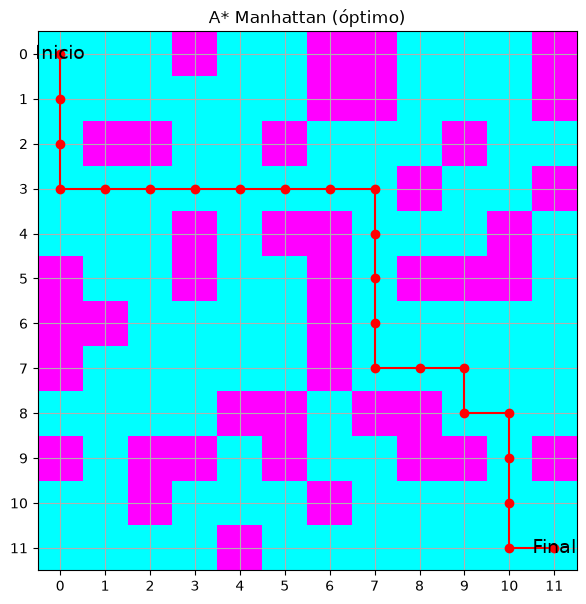

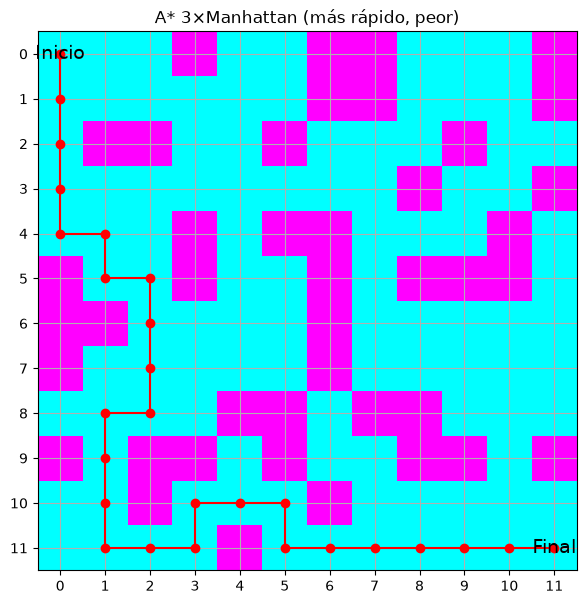

In [30]:
mostrar_mapa(mapa12, res_h["Manhattan"]["camino"], INICIO12, OBJETIVO12, "A* Manhattan (óptimo)")
mostrar_mapa(mapa12, res_h["3×Manhattan (no admisible)"]["camino"], INICIO12, OBJETIVO12, "A* 3×Manhattan (más rápido, peor)")

**Análisis Parte 2**

- Con movimientos solo en 4 direcciones, **Manhattan ≥ Euclidiana** en todos los nodos y ambas son admisibles → Manhattan **domina**: mismo costo (22) con menos expansiones (60 vs 67).
- $h=0$ es la menos informada (95 expansiones, igual a UCS).
- **3×Manhattan** expande apenas **36** nodos, pero devuelve un camino de costo **26**: va "directo" hacia la meta confiando demasiado en la estimación.
- **Manhattan es la que mejor orienta la búsqueda** sin sacrificar optimalidad.

## Parte 3 — 8-puzzle
Resuelto arriba en la sección 11 (tabla BFS vs A* h1 vs A* h2): misma longitud, y h2 reduce drásticamente los estados expandidos.

## Pregunta final — ¿Puede una búsqueda más rápida producir una solución peor?

**Sí.** Los experimentos lo muestran de tres formas:

| Experimento | Rápido | Resultado |
|---|---|---|
| Grafo, heurística que sobreestima | 5 expansiones | costo **11** (óptimo: 9) |
| Mapa 12×12, A* 3×Manhattan | 36 expansiones | costo **26** (óptimo: 22) |
| Mapa 12×12, Beam k=2 | 55 expansiones | costo **32** — y con k=1 **ninguna solución** |

La rapidez se consigue **descartando o posponiendo** partes del espacio de búsqueda. Si ese descarte se basa en información que no es una cota inferior fiable (heurística no admisible) o en un límite artificial ($k$ en Beam Search), se pueden ignorar justamente los caminos óptimos.

Pero *más rápido no siempre implica peor*: A* con Manhattan es más rápido que UCS **y** sigue siendo óptimo, porque su heurística es admisible. La clave no es la velocidad en sí, sino **si el criterio de poda conserva las garantías**.

### Uso de IA generativa

- **Herramienta:** Claude (Anthropic)
- **Propósito:** apoyo en la redacción de las interpretaciones (sección 5.2, tres casos de heurística) y revisión de estilo en las respuestas conceptuales.
- **Partes en las que se usó:** sección 5.2 (interpretación de los tres casos).

> El código, los experimentos y las conclusiones son propias; la herramienta se usó solo como apoyo para revisar redacción.

# 14. Conclusiones y transición

- Costo Uniforme prioriza el costo acumulado.
- A* combina costo acumulado y estimación del costo restante.
- Una buena heurística puede reducir la exploración.
- Beam Search reduce el uso de recursos, pero sacrifica garantías.
